In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os

# Cek posisi direktori biar gak nyasar relative path-nya
print(f"Current Directory: {os.getcwd()}")

TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"

# Load data tabular (.csv)
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Data Latih (Train) Sukses Dimuat: {train_df.shape}")
print(f"Data Uji (Test) Sukses Dimuat: {test_df.shape}")

Current Directory: d:\Tubes ML (2)\notebooks
Data Latih (Train) Sukses Dimuat: (7352, 563)
Data Uji (Test) Sukses Dimuat: (2947, 563)


In [4]:
# 1. Pisahkan Fitur (X) dan Target (y)
# Kita drop kolom 'subject' dan 'Activity' untuk mengambil fitur sensor saja
X_train = train_df.drop(['subject', 'Activity'], axis=1)
y_train_text = train_df['Activity']

X_test = test_df.drop(['subject', 'Activity'], axis=1)
y_test_text = test_df['Activity']

# 2. Mengubah teks aktivitas menjadi angka otomatis (0, 1, 2, dst)
le = LabelEncoder()
y_train = le.fit_transform(y_train_text)
y_test = le.transform(y_test_text)

# 3. Tampilkan hasil mapping labelnya biar jelas
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Hasil Mapping Label Aktivitas ke Angka:")
for nama_aktivitas, angka in mapping.items():
    print(f"Angka {angka} -> {nama_aktivitas}")

print(f"\nDimensi X_train setelah drop: {X_train.shape}")

Hasil Mapping Label Aktivitas ke Angka:
Angka 0 -> LAYING
Angka 1 -> SITTING
Angka 2 -> STANDING
Angka 3 -> WALKING
Angka 4 -> WALKING_DOWNSTAIRS
Angka 5 -> WALKING_UPSTAIRS

Dimensi X_train setelah drop: (7352, 561)


In [5]:
# Gabungkan kembali fitur X dan target y yang sudah jadi angka ke satu DataFrame
train_clean = X_train.copy()
train_clean['target'] = y_train

test_clean = X_test.copy()
test_clean['target'] = y_test

# Simpan ke folder data dengan relative path
train_clean.to_csv("../data/train_clean.csv", index=False)
test_clean.to_csv("../data/test_clean.csv", index=False)

print("Mantap! File 'train_clean.csv' & 'test_clean.csv' berhasil aman di folder data.")

Mantap! File 'train_clean.csv' & 'test_clean.csv' berhasil aman di folder data.


C:\Users\ACER\AppData\Local\Temp\ipykernel_26672\2843334563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Activity', data=train_df, palette='Set2',


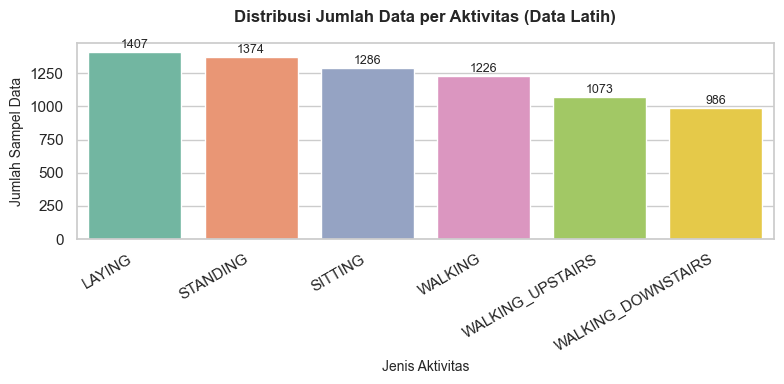

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# Hitung jumlah masing-masing aktivitas di data latih
ax = sns.countplot(x='Activity', data=train_df, palette='Set2', 
                   order=train_df['Activity'].value_counts().index)

plt.title('Distribusi Jumlah Data per Aktivitas (Data Latih)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jenis Aktivitas', fontsize=10)
plt.ylabel('Jumlah Sampel Data', fontsize=10)
plt.xticks(rotation=30, ha='right')

# Tambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()